In [ ]:
!pip install opencv-python-headless matplotlib numpy pandas
!pip install torch torchvision torchaudio
!pip install albumentations
!pip install transformers
!pip install pytesseract

In [3]:
!file indian-license-plate-dataset.zip

indian-license-plate-dataset.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [5]:
!unzip indian-license-plate-dataset.zip

Archive:  indian-license-plate-dataset.zip
  inflating: State-wise_OLX/AN/AN1.jpg  
  inflating: State-wise_OLX/AN/AN1.xml  
  inflating: State-wise_OLX/AN/AN10.jpg  
  inflating: State-wise_OLX/AN/AN10.xml  
  inflating: State-wise_OLX/AN/AN2.jpg  
  inflating: State-wise_OLX/AN/AN2.xml  
  inflating: State-wise_OLX/AN/AN4.jpg  
  inflating: State-wise_OLX/AN/AN4.xml  
  inflating: State-wise_OLX/AN/AN5.jpg  
  inflating: State-wise_OLX/AN/AN5.xml  
  inflating: State-wise_OLX/AN/AN6.jpg  
  inflating: State-wise_OLX/AN/AN6.xml  
  inflating: State-wise_OLX/AN/AN7.jpg  
  inflating: State-wise_OLX/AN/AN7.xml  
  inflating: State-wise_OLX/AP/AP1.jpg  
  inflating: State-wise_OLX/AP/AP1.xml  
  inflating: State-wise_OLX/AP/AP10.jpg  
  inflating: State-wise_OLX/AP/AP10.xml  
  inflating: State-wise_OLX/AP/AP12.jpg  
  inflating: State-wise_OLX/AP/AP12.xml  
  inflating: State-wise_OLX/AP/AP13.jpg  
  inflating: State-wise_OLX/AP/AP13.xml  
  inflating: State-wise_OLX/AP/AP14.jpg  
  inf

In [6]:
!ls video_images | head -20

car-wbs-MH01DE2780_00000.png
car-wbs-MH01DE2780_00000.xml
car-wbs-MH03AR5549_00000.jpg
car-wbs-MH03AR5549_00000.xml
car-wbs-MH12FU1014_00000.png
car-wbs-MH12FU1014_00000.xml
car-wbs-MH43AF5037_00000.png
car-wbs-MH43AF5037_00000.xml
car-wbs-MH43BU2401_00000.png
car-wbs-MH43BU2401_00000.xml
car-wbs-MH46BV0688_00000.png
car-wbs-MH46BV0688_00000.xml
car-ybs-MH43BP8173_00000.png
car-ybs-MH43BP8173_00000.xml
car-ybs-MH46AD5258_00000.png
car-ybs-MH46AD5258_00000.xml
car-ybs-MH46AD5258_00001.png
car-ybs-MH46AD5258_00001.xml
car-ybs-MH46BF2342_00000.png
car-ybs-MH46BF2342_00000.xml


In [40]:
import xml.etree.ElementTree as ET

def read_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    plate_text = None
    bbox = []

    for obj in root.findall('object'):
        plate_text = obj.find('name').text

        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        bbox = [xmin, ymin, xmax, ymax]

    return plate_text, bbox

In [46]:
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [47]:
# THRESHOLDING/SEGMENTATION
def threshold_segmentation(img):
    gray = to_gray(img)

    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    return thresh

(np.float64(-0.5), np.float64(240.5), np.float64(112.5), np.float64(-0.5))

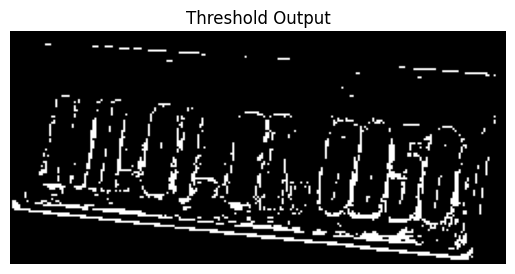

In [48]:
# Testing it
plate = extract_plate("video_images/video8_890.jpg", "video_images/video8_890.xml")

thresh = threshold_segmentation(plate)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold Output")
plt.axis("off")

In [49]:
# EDGE DETECTION (CANNY)
def edge_detection(img):
    gray = to_gray(img)
    edges = cv2.Canny(gray, 100, 200)
    return edges

(np.float64(-0.5), np.float64(240.5), np.float64(112.5), np.float64(-0.5))

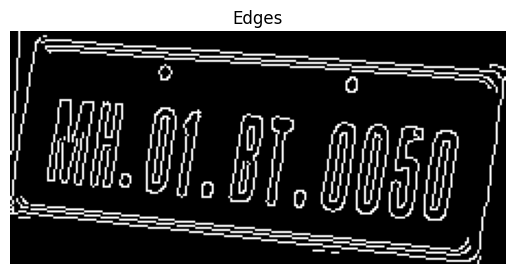

In [50]:
# Testing it
edges = edge_detection(plate)

plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis("off")

In [51]:
# CONTOUR DETECTION
def find_contours(img):
    contours, _ = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    return contours

(np.float64(-0.5), np.float64(240.5), np.float64(112.5), np.float64(-0.5))

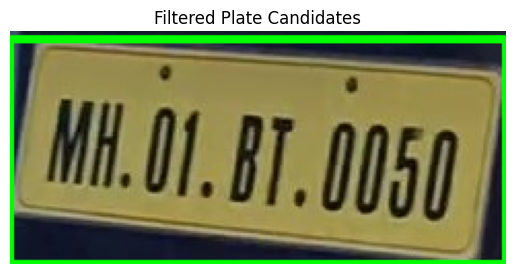

In [52]:
img_copy = plate.copy()
edges = edge_detection(plate)
contours = find_contours(edges)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    aspect_ratio = w / float(h)
    area = w * h

    # Plate-like filtering
    if 2 < aspect_ratio < 5 and 2000 < area < 50000:

        # Rectangle shape check
        approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)

        if len(approx) == 4:
            cv2.rectangle(img_copy, (x,y), (x+w,y+h), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("Filtered Plate Candidates")
plt.axis("off")

In [53]:
# CORNER DETECTION (HARRIS)
import numpy as np

def corner_detection(img):
    gray = np.float32(to_gray(img))

    corners = cv2.cornerHarris(gray, 2, 3, 0.04)

    return corners

(np.float64(-0.5), np.float64(240.5), np.float64(112.5), np.float64(-0.5))

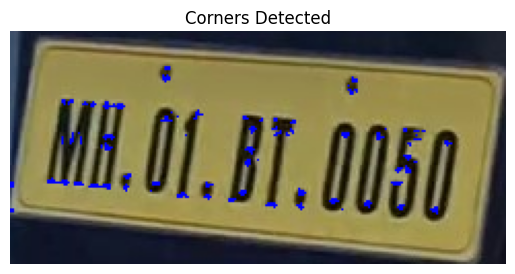

In [54]:
# Visualize Corners
corners = corner_detection(plate)

img_corner = plate.copy()
img_corner[corners > 0.01 * corners.max()] = [255, 0, 0]

plt.imshow(cv2.cvtColor(img_corner, cv2.COLOR_BGR2RGB))
plt.title("Corners Detected")
plt.axis("off")

In [41]:
import cv2
import matplotlib.pyplot as plt

def show_gt_box(image_path, xml_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    text, bbox = read_xml(xml_path)
    x1, y1, x2, y2 = bbox

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.imshow(img)
    plt.title(f"Ground Truth Plate: {text}")
    plt.axis("off")

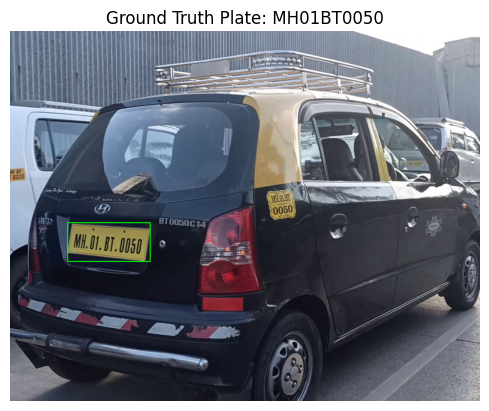

In [42]:
show_gt_box(
    "video_images/video8_890.jpg",
    "video_images/video8_890.xml"
)

In [43]:
def extract_plate_gt(image_path, xml_path):
    img = cv2.imread(image_path)
    text, bbox = read_xml(xml_path)

    x1, y1, x2, y2 = bbox
    plate = img[y1:y2, x1:x2]

    return plate, text

(np.float64(-0.5), np.float64(240.5), np.float64(112.5), np.float64(-0.5))

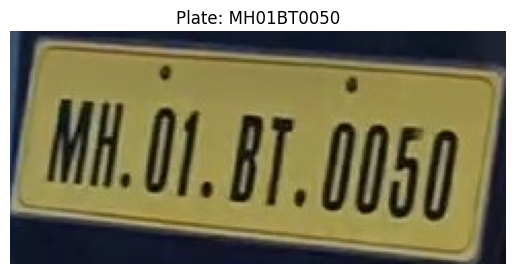

In [44]:
plate, text = extract_plate_gt(
    "video_images/video8_890.jpg",
    "video_images/video8_890.xml"
)

plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
plt.title(f"Plate: {text}")
plt.axis("off")

In [45]:
import os

image_dir = "video_images"

plates = []
labels = []

for file in os.listdir(image_dir):

    if file.endswith(".jpg"):
        img_path = os.path.join(image_dir, file)
        xml_path = img_path.replace(".jpg", ".xml")

        if os.path.exists(xml_path):
            plate, text = extract_plate_gt(img_path, xml_path)

            plates.append(plate)
            labels.append(text)

print("Total plates extracted:", len(plates))

Total plates extracted: 642


In [55]:
def preprocess_plate(img):
    img = cv2.resize(img, (128, 64))   # fixed size
    img = img / 255.0                  # normalize
    return img

In [58]:
# Apply Preprocessing
import numpy as np

processed_images = np.array([preprocess_plate(img) for img in plates])

print("Processed images shape:", processed_images.shape)

Processed images shape: (642, 64, 128, 3)


In [59]:
# Character Encoding
import string

chars = string.ascii_uppercase + string.digits

char_to_idx = {char: idx+1 for idx, char in enumerate(chars)}
char_to_idx["<blank>"] = 0

idx_to_char = {idx: char for char, idx in char_to_idx.items()}

In [88]:
MAX_LEN = 10

In [89]:
# Encode Labels
def encode_label(text):
    return [char_to_idx[c] for c in text if c in char_to_idx]

encoded_labels = [encode_label(label) for label in labels]

print(labels[0])
print(encoded_labels[0])

MH03DK2961
[13, 8, 27, 30, 4, 11, 29, 36, 33, 28]


In [90]:
# Padding Labels
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_labels = pad_sequences(
    encoded_labels,
    maxlen=MAX_LEN,
    padding='post'
)

print("Label shape:", padded_labels.shape)

Label shape: (642, 10)


In [91]:
# T-T-S
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    processed_images, padded_labels, test_size=0.3
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5
)

print("Train size:", len(X_train))

Train size: 449


In [92]:
# Pytorch Dataset
import torch

class ANPRDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx]).permute(2,0,1).float()
        label = torch.tensor(self.labels[idx]).long()
        return img, label

In [93]:
# Data Loader
from torch.utils.data import DataLoader

train_dataset = ANPRDataset(X_train, y_train)
val_dataset = ANPRDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print("Dataset ready!")

Dataset ready!


In [94]:
# CNN
import torch.nn as nn
import torchvision.models as models

class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        base_model = models.resnet18(pretrained=True)

        # Remove last layers
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-2])

    def forward(self, x):
        x = self.feature_extractor(x)
        return x

In [114]:
# Transformer Decoder
class TransformerDecoder(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()

        self.transformer = nn.Transformer(
            d_model=feature_dim,
            nhead=8,
            num_encoder_layers=2,
            num_decoder_layers=2
        )

    def forward(self, x):
        return self.transformer(x, x)

In [120]:
# Combined
class ANPRModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = CNNEncoder()
        self.transformer = TransformerDecoder(512)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.cnn(x)

        B, C, H, W = features.shape

        features = features.view(B, C, -1)
        features = features.permute(0, 2, 1)

        if features.size(1) < MAX_LEN:
          pad_size = MAX_LEN - features.size(1)
          padding = torch.zeros(features.size(0), pad_size, features.size(2)).to(features.device)
          features = torch.cat([features, padding], dim=1)
        else:
          features = features[:, :MAX_LEN, :]

        features = features.permute(1, 0, 2)

        output = self.transformer(features)

        output = output.permute(1, 0, 2)

        output = self.fc(output)

        return output

In [121]:
num_classes = len(char_to_idx)

model = ANPRModel(num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model ready!")

Model ready!


In [122]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=0)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [123]:
  def train_model(model, train_loader, epochs=5):

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for imgs, labels in train_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)   # (B, MAX_LEN, num_classes)

            B, T, C = outputs.shape

            outputs = outputs.reshape(-1, C)
            labels = labels.reshape(-1)

            if outputs.shape[0] != labels.shape[0]:
              min_len = min(outputs.shape[0], labels.shape[0])
              outputs = outputs[:min_len]
              labels = labels[:min_len]

            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [124]:
train_model(model, train_loader, epochs=5)

Epoch 1, Loss: 68.7169
Epoch 2, Loss: 36.1460
Epoch 3, Loss: 24.0198
Epoch 4, Loss: 18.1717
Epoch 5, Loss: 12.9057


In [125]:
# Prediction
def predict_plate(model, img):

    model.eval()

    img = preprocess_plate(img)
    img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)   # (1, MAX_LEN, num_classes)

    output = output.squeeze(0)  # (MAX_LEN, num_classes)

    pred_indices = torch.argmax(output, dim=1).cpu().numpy()

    # Convert to characters
    pred_text = ""
    for idx in pred_indices:
        if idx != 0:
            pred_text += idx_to_char.get(idx, "")

    return pred_text

In [126]:
# Testing
img_path = "video_images/video8_890.jpg"

img = cv2.imread(img_path)

pred = predict_plate(model, img)

print("Predicted Plate:", pred)

Predicted Plate: MH33333377


In [127]:
def predict_batch(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:

            imgs = imgs.to(device)

            outputs = model(imgs)   # (B, MAX_LEN, num_classes)

            preds = torch.argmax(outputs, dim=2)  # (B, MAX_LEN)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_preds, all_labels

In [128]:
def decode_sequence(seq):
    text = ""
    for idx in seq:
        if idx != 0:
            text += idx_to_char.get(idx, "")
    return text

In [132]:
def decode_sequence(seq):
    text = ""
    for idx in seq:
        if idx != 0:
            text += idx_to_char.get(idx, "")
    return text

In [133]:
def character_accuracy(preds, labels):

    total_chars = 0
    correct_chars = 0

    for p, l in zip(preds, labels):

        p_text = decode_sequence(p)
        l_text = decode_sequence(l)

        min_len = min(len(p_text), len(l_text))

        for i in range(min_len):
            if p_text[i] == l_text[i]:
                correct_chars += 1

        total_chars += len(l_text)

    return correct_chars / total_chars

In [134]:
def full_plate_accuracy(preds, labels):

    correct = 0

    for p, l in zip(preds, labels):

        p_text = decode_sequence(p)
        l_text = decode_sequence(l)

        if p_text == l_text:
            correct += 1

    return correct / len(labels)

In [135]:
preds, true_labels = predict_batch(model, val_loader)

char_acc = character_accuracy(preds, true_labels)
full_acc = full_plate_accuracy(preds, true_labels)

print("Character Accuracy:", char_acc)
print("Full Plate Accuracy:", full_acc)

Character Accuracy: 0.827186512118019
Full Plate Accuracy: 0.08333333333333333
